In [ ]:
!pip install pyspark --quiet
print('succes!!')

succes!!


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark=SparkSession.builder\
.appName('Day4_BigData_Sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()
print('succes!!')
print("Saprk version:",spark.version)
print('ACTIVE')

succes!!
Saprk version: 4.0.2
ACTIVE


In [ ]:
df_bronze=spark.read\
.option('header','true')\
.option('inferSchema','true')\
.csv('large_sales_data.csv')
print('======******************BRONZE LAYER->RAW DATA**********************==========')
print("rows:",df_bronze.count())
print("columns:",len(df_bronze.columns))
print("names:",df_bronze.columns)
df_bronze.printSchema()

======******************BRONZE LAYER->RAW DATA**********************==========
rows: 5000
columns: 13
names: ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print("First 5 rows:")
df_bronze.show(5,truncate=False)

print("\nBasic statistics for numeric columns:")
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [ ]:
df_bronze.write\
    .mode('overwrite')\
    .parquet('sales_bronze.parquet')
print('bronze parquet saved:sales_bronze.parquet')

import os

def get_dir_size(path):
  """Get total size of a file or directory in KB,"""
  if os.path.isfile(path):
      return os.path.getsize(path)/1024
  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total+= os.path.getsize(os.path.join(dirpath,f))
  return total/1024
csv_size=get_dir_size('large_sales_data.csv')
print('csv size:',csv_size)
parquet_size=get_dir_size('sales_bronze.parquet')
print('parquet size:',parquet_size)
reduction=(csv_size-parquet_size)/csv_size * 100
print(f'reduction: {reduction:.2f}% reduced')

bronze parquet saved:sales_bronze.parquet
csv size: 529.3125
parquet size: 55.09765625
reduction: 89.59% reduced


In [ ]:
df_silver = df_bronze\
    .dropDuplicates()\
    .dropna(subset = ['order_id','product','revenue'])

df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)

df_silver=df_silver\
    .withColumn('order_year',year('order_date'))\
    .withColumn('order_month',month('order_date'))

df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(F.col('revenue') > 10000, 'high')
     .when(F.col('revenue') > 4000, 'medium')
     .otherwise('low')
)

print(f'silver layer rows;{df_silver.count()}')
print('New columns added:order_year,order_month,revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category')

silver layer rows;5000
New columns added:order_year,order_month,revenue_category


DataFrame[product: string, revenue: int, order_year: int, order_month: int, revenue_category: string]

In [ ]:
df_silver.write\
    .mode('overwrite')\
    .parquet('sales_silver.parquet')

print('Silver parquet saved:sales_silver.parquet')
print(f'silver size:{get_dir_size("sales_silver.parquet"):.1f} KB')

df_verify=spark.read.parquet('sales_silver.parquet')
print("\n === verify Silver Layer ===")
print(f"Read back rows:{df_verify.count()}(should match silver count)")
df_verify.printSchema()

Silver parquet saved:sales_silver.parquet
silver size:59.8 KB

 === verify Silver Layer ===
Read back rows:5000(should match silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
!pip install twilio --quiet

In [ ]:
import os
from getpass import getpass
from twilio.rest import Client

# --- Twilio credentials ---
TW_SID = os.environ.get('TWILIO_SID')
TW_TOKEN = os.environ.get('TWILIO_TOKEN')


if not TW_SID or not TW_TOKEN:
    print("Enter your Twilio Account SID and Auth Token:")
    TW_SID = getpass("Twilio SID: ")
    TW_TOKEN = getpass("Twilio Token: ")
    os.environ['TWILIO_SID'] = TW_SID
    os.environ['TWILIO_TOKEN'] = TW_TOKEN


FROM = 'whatsapp:+14155238886'
TO = input("Enter your whatsApp number").strip()
if not TO.startswith('whatsapp:'):
  TO=f'whatsapp:{TO}'

client =Client(TW_SID,TW_TOKEN)

msg= client.messages.create(
    body="Hello from salomi da maapla",
    from_=FROM,
    to=TO
)

print("msg sent successfully")
print("msg SID:",msg.sid)

Enter your whatsApp number+919500876403
msg sent successfully
msg SID: SMd9cfaaa2cc21fd060e47c3879a1ac771


In [ ]:
top_products=df_silver\
    .groupBy('product')\
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.avg('revenue').alias('avg_revenue')
    )\
    .orderBy('total_revenue',ascending=False)\
    .limit(5)

print("Top 5 products by revenue:")
top_products.show()

Top 5 products by revenue:
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|       avg_revenue|
+-------+-------------+----------+------------------+
| Laptop|    182700000|       502|363944.22310756973|
| Tablet|    135104000|       532| 253954.8872180451|
|Monitor|     82126000|       481|170740.12474012474|
|Printer|     44544000|       488| 91278.68852459016|
|Speaker|     16317000|       470| 34717.02127659575|
+-------+-------------+----------+------------------+



In [ ]:
region_revenue=df_silver\
    .groupBy('region')\
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('total_orders'),
        F.countDistinct('customer_name').alias('unique_customers')
    )\
    .orderBy('total_revenue',ascending=False)

print("Top 5 products by revenue:")
region_revenue.show()

Top 5 products by revenue:
+------+-------------+------------+----------------+
|region|total_revenue|total_orders|unique_customers|
+------+-------------+------------+----------------+
|  West|    198275600|        2021|              15|
| South|    147145900|        1483|              15|
| North|     99878400|         995|              15|
|  East|     50547700|         501|              15|
+------+-------------+------------+----------------+



In [ ]:
west_region_revenue=df_silver\
    .groupBy('region')\
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('total_orders'),
        F.countDistinct('customer_name').alias('unique_customers'),
        F.collect_set('customer_name').alias('customer_names')
    )\
    .orderBy('total_revenue',ascending=False)\
    .filter(F.col('region')=='West')

print("Top 5 products by revenue:")
region_revenue.show(truncate=False)

Top 5 products by revenue:
+------+-------------+------------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|region|total_revenue|total_orders|unique_customers|customer_names                                                                                                                                                                                     |
+------+-------------+------------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|West  |198275600    |2021        |15              |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priya Patel, Suresh Rao, Kavya Nambiar, Ami

In [ ]:
monthly_revenue=df_silver\
    .groupBy('order_month')\
    .agg(
        F.sum('revenue').alias('monthly_revenue'),
        F.count('order_id').alias('monthly_orders')
    )\
    .orderBy('order_month')

print("Monthly Revenue:")
monthly_revenue.show()
#

Monthly Revenue:
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|       41068200|           423|
|          2|       34485400|           375|
|          3|       40031200|           451|
|          4|       38857100|           390|
|          5|       39984500|           423|
|          6|       40707400|           390|
|          7|       42640700|           405|
|          8|       43718500|           418|
|          9|       37640200|           398|
|         10|       47839000|           479|
|         11|       44577100|           419|
|         12|       44298300|           429|
+-----------+---------------+--------------+



In [ ]:
monthly_orders = df_silver \
    .withColumn("month_name", F.date_format(F.col("order_date"), "MMMM")) \
    .groupBy("order_month", "month_name") \
    .agg(
        F.sum("revenue").alias("monthly_revenue"),
        F.count("order_id").alias("monthly_orders")
    ) \
    .orderBy("order_month")

print("Monthly Revenue:")
monthly_orders.show(truncate=False)
gold_month=monthly_orders
gold_month.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('Gold parquet saved:gold_monthly_trend.parquet')

Monthly Revenue:
+-----------+----------+---------------+--------------+
|order_month|month_name|monthly_revenue|monthly_orders|
+-----------+----------+---------------+--------------+
|1          |January   |41068200       |423           |
|2          |February  |34485400       |375           |
|3          |March     |40031200       |451           |
|4          |April     |38857100       |390           |
|5          |May       |39984500       |423           |
|6          |June      |40707400       |390           |
|7          |July      |42640700       |405           |
|8          |August    |43718500       |418           |
|9          |September |37640200       |398           |
|10         |October   |47839000       |479           |
|11         |November  |44577100       |419           |
|12         |December  |44298300       |429           |
+-----------+----------+---------------+--------------+

Gold parquet saved:gold_monthly_trend.parquet


In [ ]:
gold_region=region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold parquet saved:gold_region_revenue.parquet')

gold_products=df_silver\
      .groupBy('product','category')\
      .agg(
          F.sum('revenue').alias('total_revenue'),
          F.count('order_id').alias('units_sold'),
          spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
          F.max('revenue').alias('largest_order')
      )\
      .orderBy('total_revenue',ascending=False)

gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('Gold 2 saved:gold_product_summary.parquet')

Gold parquet saved:gold_region_revenue.parquet
Gold 2 saved:gold_product_summary.parquet


In [ ]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()
product_pd=spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd=spark.read.parquet('gold_monthly_trend.parquet').toPandas()

print('Gold tables converted to Pandas:')
print(f'Region :{region_pd.shape}')
print(f'Product: {product_pd.shape}')
print(f'Monthly: {monthly_pd.shape}')

#sort for plotting
region_pd=region_pd.sort_values('total_revenue',ascending=False)
products_pd=product_pd.sort_values('total_revenue',ascending=False)
monthly_pd=monthly_pd.sort_values('order_month')


Gold tables converted to Pandas:
Region :(4, 4)
Product: (10, 6)
Monthly: (12, 4)


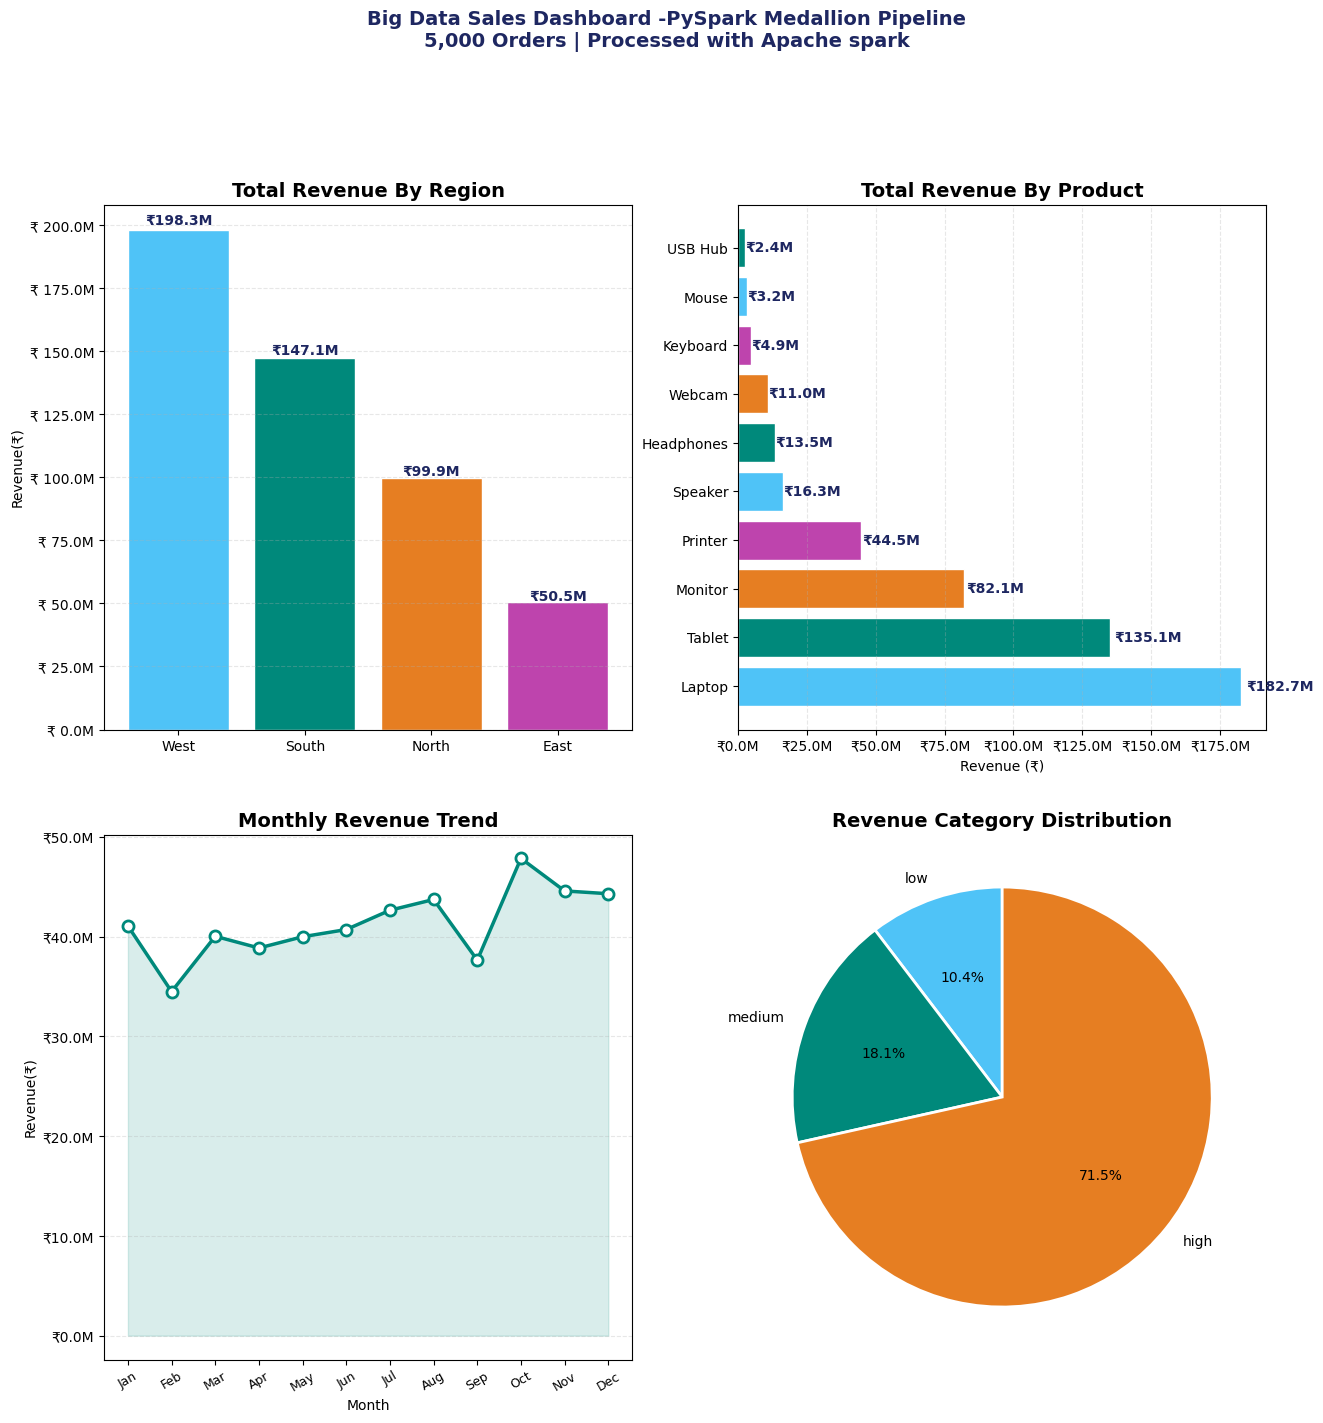

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(15,15))
fig.suptitle(
    'Big Data Sales Dashboard -PySpark Medallion Pipeline\n'
    '5,000 Orders | Processed with Apache spark',
    fontsize=14,fontweight='bold',color='#1E2761',y=1.01
)

colors4=['#4FC3F7','#00897B','#E67E22','#BE44AD','E74C3C']

# PANEL 1 REVENUE BY REGION
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
    ax1.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()*1.01,
        f'₹{bar.get_height()/1e6:.1f}M',
        ha='center',fontsize=10,fontweight='bold',color='#1E2761'
    )
ax1.set_title('Total Revenue By Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue(₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1e6: .1f}M'))

ax1.grid(axis='y',linestyle='--',alpha=0.3)


## PANEL 2 TOTAL REVENUE BY PRODUCT(HORIZONTAL)
ax2 = axes[0][1]
bars1 = ax2.barh(product_pd['product'],product_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')
for bar in bars1:
    ax2.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height()/2,
        f'₹{bar.get_width()/1e6:.1f}M',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )
ax2.set_title('Total Revenue By Product', fontsize=14, fontweight='bold')
ax2.set_xlabel('Revenue (₹)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax2.grid(axis='x', linestyle='--', alpha=0.3)

# PANEL 4 REVENUE BY REGION (PIE CHART)
ax4=axes[1][1]
rev_cat=df_silver.groupBy('revenue_category')\
    .count().orderBy('count').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=colors4[:len(rev_cat)],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Revenue Category Distribution',fontsize=14,fontweight='bold');



#panel 3:Monthly Revenue Trend
ax3=axes[1][0]
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels=[month_names[m-1] for m in monthly_pd['order_month']]
ax3.plot(monthly_labels,monthly_pd['monthly_revenue'],
         marker='o',linewidth=2.5,color='#00897B',
         markersize=8,markerfacecolor='white',markeredgewidth='2')

ax3.fill_between(range(len(monthly_labels)),
                 monthly_pd['monthly_revenue'],
                 color='#00897B',alpha=0.15)

ax3.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Revenue(₹)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
ax3.grid(axis='y',linestyle='--',alpha=0.3)
ax3.tick_params(axis='x',rotation=30,labelsize=9)